# Latent feature space investigation

We can also reduce our dimensionality by selecting a subset of genes.

pattern: /mnt/bulk-saturn/maralampert/genhist/experiments/20260302_gene_subselection/encoding/**/*.h5
found 996 h5 files (recursive search)
   /mnt/bulk-saturn/maralampert/genhist/experiments/20260302_gene_subselection/encoding/TCGA-3C-AAAU.h5
   /mnt/bulk-saturn/maralampert/genhist/experiments/20260302_gene_subselection/encoding/TCGA-3C-AALI.h5
   /mnt/bulk-saturn/maralampert/genhist/experiments/20260302_gene_subselection/encoding/TCGA-3C-AALJ.h5
   /mnt/bulk-saturn/maralampert/genhist/experiments/20260302_gene_subselection/encoding/TCGA-3C-AALK.h5
   /mnt/bulk-saturn/maralampert/genhist/experiments/20260302_gene_subselection/encoding/TCGA-4H-AAAK.h5
   /mnt/bulk-saturn/maralampert/genhist/experiments/20260302_gene_subselection/encoding/TCGA-5L-AAT0.h5
   /mnt/bulk-saturn/maralampert/genhist/experiments/20260302_gene_subselection/encoding/TCGA-5L-AAT1.h5
   /mnt/bulk-saturn/maralampert/genhist/experiments/20260302_gene_subselection/encoding/TCGA-5T-A9QA.h5
   /mnt/bulk-saturn/maralamp

/mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


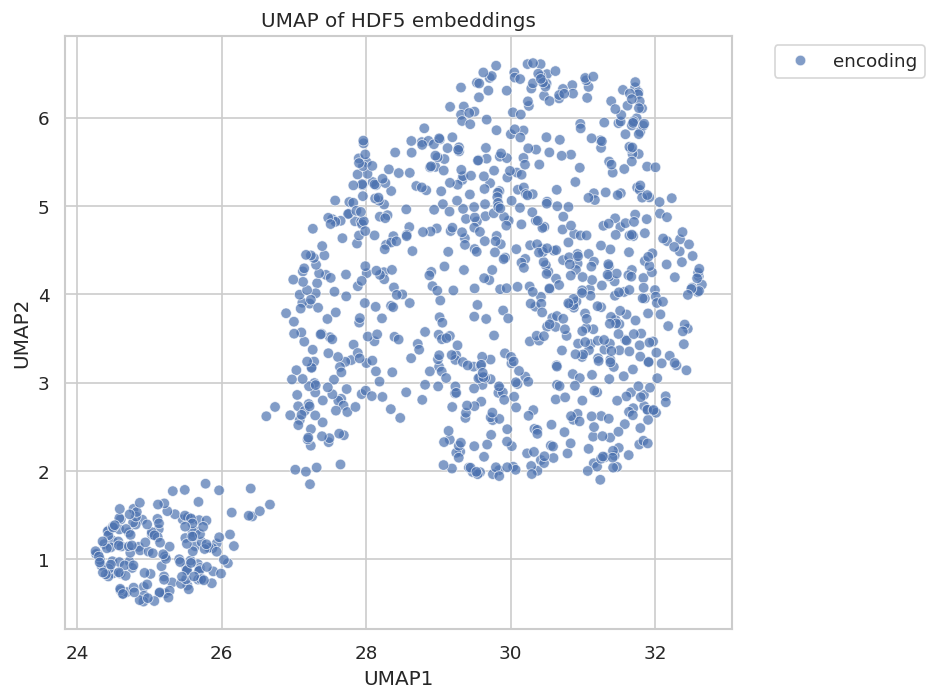

In [10]:
import os, glob
from pathlib import Path

import h5py
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP     # pip install umap-learn

sns.set(style="whitegrid")

# ------------------------------------------------------------------
# 1. gather all the .h5 files under the directory (train/test subfolders)
# ------------------------------------------------------------------
h5_file_path = "/mnt/bulk-saturn/maralampert/genhist/experiments/20260302_gene_subselection/encoding/"
# glob recursive in case files sit directly in this folder or deeper
pattern = os.path.join(h5_file_path, "**", "*.h5")
file_list = sorted(glob.glob(pattern, recursive=True))
print(f"pattern: {pattern}")
print(f"found {len(file_list)} h5 files (recursive search)")
for fp in file_list[:10]:
    print("  ", fp)
if len(file_list) > 10:
    print("  ...")

# fallback: if the recursive search did not find anything, try non-recursive
if not file_list:
    pattern2 = os.path.join(h5_file_path, "*", "*.h5")
    file_list = sorted(glob.glob(pattern2))
    print(f"fallback pattern: {pattern2}")
    print(f"found {len(file_list)} h5 files (non-recursive)")
    for fp in file_list[:10]:
        print("  ", fp)
    if len(file_list) > 10:
        print("  ...")

embs, labels = [], []
for fp in file_list:
    with h5py.File(fp, "r") as f:
        # pick the first dataset you find – adjust if you know the name
        key = next(iter(f.keys()), None)
        if key is None:
            print(f"warning: {fp} contains no datasets, skipping")
            continue
        dataset = f[key]
        print(f"reading {fp} -> {type(dataset)} shape={getattr(dataset, 'shape', None)}")
        if isinstance(dataset, h5py.Dataset):
            arr = np.squeeze(dataset[()])  # dataset[()] converts h5py Dataset to numpy array
        else:
            print(f"skipping {fp} (not a Dataset)")
            continue  # skip if not a Dataset
    if arr.size == 0:
        print(f"skipping {fp} (empty array)")
        continue
    if arr.ndim > 1:
        arr = arr.ravel()
    embs.append(arr)

    # label by folder name (train/test) or whatever you prefer
    labels.append(Path(fp).parent.name)

print(f"collected {len(embs)} embeddings")
if len(embs) == 0:
    raise RuntimeError("no embeddings were collected – verify the path and file contents")

X = np.vstack(embs)                # shape (n_samples, dim)
print("loaded", X.shape, "embeddings")

# ------------------------------------------------------------------
# 2. compute UMAP
# ------------------------------------------------------------------
reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X)  # shape (n_samples, 2)

# ------------------------------------------------------------------
# 3. plot
# ------------------------------------------------------------------
df_umap = pd.DataFrame(
    {"UMAP1": X_umap[:, 0], "UMAP2": X_umap[:, 1], "label": labels}
)

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=df_umap, x="UMAP1", y="UMAP2", hue="label", alpha=0.7, s=40
)
ax.set_title("UMAP of HDF5 embeddings")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
